
# Packet-Level Exploratory Data Analysis

This notebook explores `packet_sample_seed1.csv` before preprocessing and model training.

The main goals are to:

- verify the sampled class distribution;
- inspect data types, missing values, duplicates, and constant columns;
- understand important packet, protocol, timing, and rolling-window features;
- identify skewed variables, outliers, and highly correlated features;
- record preprocessing decisions for the Phase 2 packet-level models.

`binary_label` and `attack_type` are used only for EDA and later evaluation. They must not be passed into unsupervised model training.


## Setup, load metadata and sampled packet dataset

In [1]:

import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 60)
pd.set_option("display.max_rows", 100)

METADATA_FILE_NAME = "packet_sample_seed1.metadata.json"

PROJECT_ROOT = Path("..")
META_PATH = PROJECT_ROOT / "data" / "samples" / METADATA_FILE_NAME

with open(META_PATH, "r") as f:
    metadata = json.load(f)

DATA_PATH = PROJECT_ROOT / metadata["output_path"]
df = pd.read_csv(DATA_PATH, low_memory=False)

BINARY_COL = "binary_label"
ATTACK_COL = "attack_type"
SOURCE_COL = "source_file"

print("Dataset path:", DATA_PATH)
print("Dataset shape:", df.shape)
print("Memory usage: {:.2f} MB".format(df.memory_usage(deep=True).sum() / 1024**2))
df.head()


Dataset path: ../data/samples/packet_sample_seed1.csv
Dataset shape: (205041, 138)
Memory usage: 407.05 MB


,stream,src_mac,dst_mac,src_ip,dst_ip,src_port,dst_port,inter_arrival_time,time_since_previously_displayed_frame,port_class_dst,l4_tcp,l4_udp,ttl,eth_size,tcp_window_size,payload_entropy,handshake_version,handshake_cipher_suites_length,handshake_ciphersuites,handshake_extensions_length,tls_server,handshake_sig_hash_alg_len,http_request_method,http_host,http_response_code,user_agent,dns_server,dns_query_type,dns_len_qry,dns_interval,...,src_ip_60_var,src_ip_mac_60_count,src_ip_mac_60_mean,src_ip_mac_60_var,channel_60_count,channel_60_mean,channel_60_var,stream_jitter_60_sum,stream_jitter_60_mean,stream_jitter_60_var,ntp_interval,most_freq_spot,min_et,q1,min_e,var_e,q1_e,sum_p,min_p,max_p,med_p,average_p,var_p,q3_p,q1_p,iqr_p,l3_ip_dst_count,attack_type,binary_label,source_file
0,3308,ac:17:02:05:34:27,3c:18:a0:41:c3:a0,192.168.137.41,109.95.152.66,38816,443,2109.894808,0.000185,1,1,0,64,60,0,0.000000,-1,0,-1,0,none,0,none,none,0,none,none,NaN,0,0.0,...,7717.727472,489.0,106.760736,7717.727472,14.0,347.928571,6.006796e+05,1054.041652,75.288689,79105.166968,0.0,443,26.0,32.0,60.0,423167.578947,66.0,3920.0,6.0,2908.0,12.0,196.00,423167.578947,19.0,12.0,7.0,9.0,Benign,benign,BenignTraffic.csv
1,7463,3c:18:a0:41:c3:a0,ac:17:02:05:34:27,157.249.81.141,192.168.137.41,443,60200,4848.002092,0.000290,3,1,0,49,66,65024,0.000000,-1,0,-1,0,none,0,none,none,0,none,none,NaN,0,0.0,...,11276.004263,360.0,101.686111,11276.004263,741.0,107.080972,9.614472e+03,2391.243426,265.693714,635068.703264,0.0,443,32.0,32.0,66.0,10677.292105,66.0,1173.0,12.0,387.0,15.5,58.65,10582.239474,32.0,12.0,20.0,9.0,Benign,benign,BenignTraffic.csv
2,3000,ac:17:02:05:34:27,3c:18:a0:41:c3:a0,192.168.137.41,157.249.81.141,54061,443,1901.971732,0.003855,1,1,0,64,74,14600,0.000000,-1,0,-1,0,none,0,none,none,0,none,none,NaN,0,0.0,...,7216.531365,492.0,105.514228,7216.531365,743.0,108.009421,9.886020e+03,947.623914,947.623914,NaN,0.0,443,32.0,32.0,66.0,2116.471053,66.0,667.0,12.0,208.0,19.5,33.35,2097.081579,28.0,12.0,16.0,9.0,Benign,benign,BenignTraffic.csv
3,27,Amazon Echo Show,Amazon Echo Dot 2,192.168.137.172,192.168.137.58,55444,55444,3902.830519,0.003104,3,0,1,64,60,0,3.201876,-1,0,-1,0,none,0,none,none,0,none,none,NaN,0,0.0,...,22257.704121,200.0,109.380000,22257.704121,228.0,87.526316,1.457988e+04,60.024567,0.275342,1.852810,0.0,55444,26.0,26.0,60.0,0.000000,60.0,360.0,18.0,18.0,18.0,18.00,0.000000,18.0,18.0,0.0,50.0,Benign,benign,BenignTraffic.csv
4,0,3c:18:a0:41:c3:a0,Arlo Q Indoor Camera,99.81.244.93,192.168.137.175,443,56891,23.178632,0.000001,3,1,0,231,66,4415,0.000000,-1,0,-1,0,none,0,none,none,0,none,none,NaN,0,0.0,...,0.000000,699.0,66.000000,0.000000,1585.0,999.589274,1.186071e+06,23.178632,0.014596,0.003870,0.0,56891,32.0,1480.0,66.0,502105.431579,1514.0,24856.0,12.0,2908.0,1460.0,1242.80,502105.431579,1460.0,1460.0,0.0,3.0,Benign,benign,BenignTraffic.csv



## Dataset overview

Start by checking whether the number of rows, number of columns, labels, and source files match the sampling metadata.


In [2]:

overview = pd.DataFrame({
    "value": [
        len(df),
        df.shape[1],
        df[BINARY_COL].nunique(dropna=False),
        df[ATTACK_COL].nunique(dropna=False),
        df[SOURCE_COL].nunique(dropna=False)
    ]
}, index=[
    "Rows",
    "Columns",
    "Binary classes",
    "Traffic types",
    "Source files"
])

display(overview)
print("Metadata seed:", metadata.get("seed"))
print("Metadata total rows:", metadata.get("total_rows"))
print("Rows match metadata:", len(df) == metadata.get("total_rows"))


,value
Rows,205041
Columns,138
Binary classes,2
Traffic types,6
Source files,6


Metadata seed: 1
Metadata total rows: 205041
Rows match metadata: True


## Class distribution

,count,percentage
binary_label,,
benign,200000,97.541
attack,5041,2.459


,count,percentage
attack_type,,
Benign,200000,97.541
DDoS-HTTP Flood,833,0.406
DoS-HTTP Flood,364,0.178
DNS Spoofing,3178,1.550
Brute Force,404,0.197
XSS,262,0.128


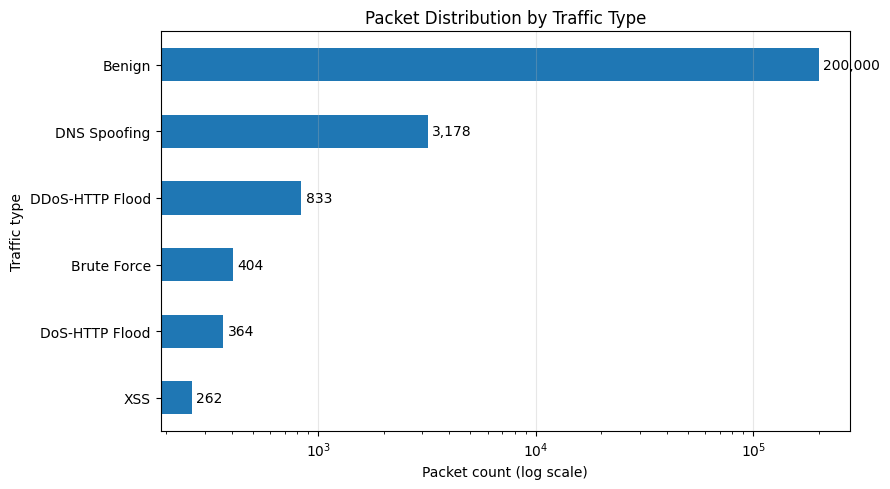

In [3]:

binary_summary = df[BINARY_COL].value_counts().rename_axis(BINARY_COL).to_frame("count")
binary_summary["percentage"] = binary_summary["count"] / len(df) * 100

type_order = ["Benign", "DDoS-HTTP Flood", "DoS-HTTP Flood", "DNS Spoofing", "Brute Force", "XSS"]
attack_summary = df[ATTACK_COL].value_counts().reindex(type_order).dropna().rename_axis(ATTACK_COL).to_frame("count")
attack_summary["percentage"] = attack_summary["count"] / len(df) * 100

display(binary_summary.round(3))
display(attack_summary.round(3))

ax = attack_summary["count"].sort_values().plot(kind="barh", figsize=(9, 5), logx=True)

for i, value in enumerate(attack_summary["count"].sort_values()):
    ax.text(value * 1.05, i, f"{int(value):,}", va="center")

ax.set_xlabel("Packet count (log scale)")
ax.set_ylabel("Traffic type")
ax.set_title("Packet Distribution by Traffic Type")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()



The sampled dataset is intentionally imbalanced because benign traffic should represent roughly 97–98% of the packets. Accuracy alone will therefore be misleading. Later models should also report precision, recall, F1, PR-AUC, ROC-AUC, FPR, and FNR.


## Data types and column groups

In [4]:

dtype_summary = df.dtypes.astype(str).value_counts().rename_axis("dtype").to_frame("column_count")
object_cols = df.select_dtypes(include="object").columns.tolist()
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

display(dtype_summary)
print("Numeric columns:", len(numeric_cols))
print("Object columns:", len(object_cols))
print()
print("Object columns:")
print(object_cols)


/var/folders/rf/t52_tqh94zzbcs4g3_xbghnh0000gn/T/ipykernel_66612/1133459834.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  object_cols = df.select_dtypes(include="object").columns.tolist()


,column_count
dtype,
float64,97
int64,22
str,19


Numeric columns: 119
Object columns: 19

Object columns:
['src_mac', 'dst_mac', 'src_ip', 'dst_ip', 'handshake_version', 'tls_server', 'http_request_method', 'http_host', 'user_agent', 'dns_server', 'device_mac', 'eth_src_oui', 'eth_dst_oui', 'highest_layer', 'http_uri', 'http_content_type', 'attack_type', 'binary_label', 'source_file']


In [5]:

object_summary = pd.DataFrame({
    "unique_values": df[object_cols].nunique(dropna=True),
    "missing_count": df[object_cols].isna().sum(),
    "missing_percentage": df[object_cols].isna().mean() * 100
}).sort_values("unique_values", ascending=False)

display(object_summary.round(2))


,unique_values,missing_count,missing_percentage
dst_ip,709,13304,6.49
src_ip,700,13304,6.49
http_uri,343,0,0.00
dns_server,137,0,0.00
user_agent,130,0,0.00
dst_mac,94,0,0.00
device_mac,79,0,0.00
src_mac,79,0,0.00
tls_server,52,0,0.00
eth_dst_oui,38,0,0.00


## Missing and infinite values

In [6]:

missing_summary = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percentage": df.isna().mean() * 100,
    "dtype": df.dtypes.astype(str),
    "unique_non_null": df.nunique(dropna=True)
}).sort_values("missing_percentage", ascending=False)

missing_summary = missing_summary[missing_summary["missing_count"] > 0]
display(missing_summary.head(25).round(2))

numeric_df = df[numeric_cols].replace([np.inf, -np.inf], np.nan)
original_missing = df[numeric_cols].isna().sum()
inf_counts = (numeric_df.isna().sum() - original_missing).sort_values(ascending=False)
inf_counts = inf_counts[inf_counts > 0]

print("Columns containing positive or negative infinity:")
display(inf_counts.to_frame("infinite_count"))


,missing_count,missing_percentage,dtype,unique_non_null
dns_query_type,179502,87.54,float64,5
src_ip_mac_1_var,63895,31.16,float64,33421
src_ip_1_var,63794,31.11,float64,36543
stream_jitter_1_var,60103,29.31,float64,144913
stream_1_var,50326,24.54,float64,41065
stream_jitter_5_var,43969,21.44,float64,160991
channel_1_var,42769,20.86,float64,51655
src_ip_5_var,35989,17.55,float64,77021
stream_jitter_10_var,34855,17.00,float64,170173
stream_5_var,34014,16.59,float64,48089


Columns containing positive or negative infinity:


,infinite_count


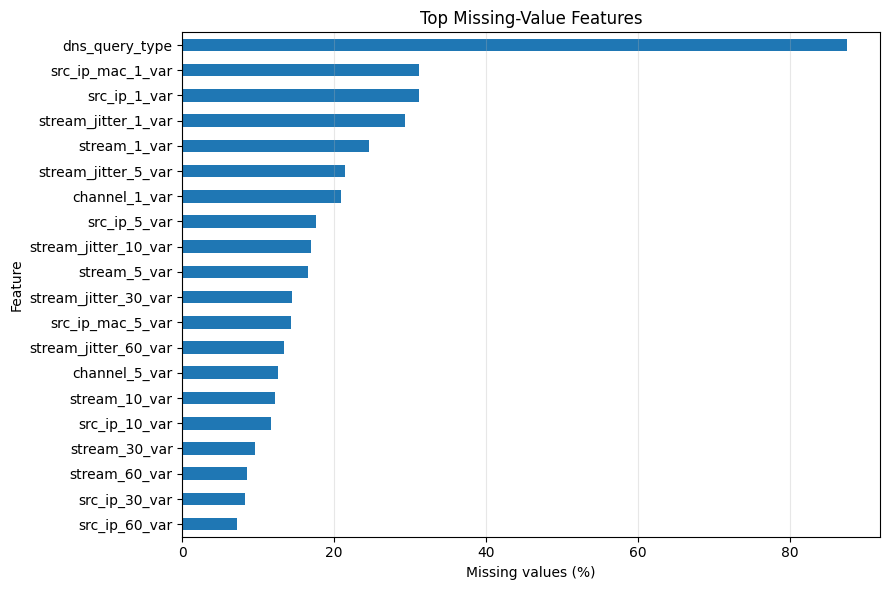

In [7]:

if len(missing_summary) > 0:
    top_missing = missing_summary.head(20).sort_values("missing_percentage")
    ax = top_missing["missing_percentage"].plot(kind="barh", figsize=(9, 6))
    ax.set_xlabel("Missing values (%)")
    ax.set_ylabel("Feature")
    ax.set_title("Top Missing-Value Features")
    ax.grid(axis="x", alpha=0.3)
    plt.tight_layout()
    plt.show()


In [8]:

missing_features = missing_summary.head(12).index.tolist()

if missing_features:
    missing_by_class = df.groupby(BINARY_COL)[missing_features].apply(lambda x: x.isna().mean() * 100)
    display(missing_by_class.round(2))


,dns_query_type,src_ip_mac_1_var,src_ip_1_var,stream_jitter_1_var,stream_1_var,stream_jitter_5_var,channel_1_var,src_ip_5_var,stream_jitter_10_var,stream_5_var,stream_jitter_30_var,src_ip_mac_5_var
binary_label,,,,,,,,,,,,
attack,97.32,20.13,21.54,23.67,21.72,14.52,12.64,13.19,10.57,11.78,8.29,10.12
benign,87.30,31.44,31.35,29.46,24.62,21.62,21.07,17.66,17.16,16.71,14.62,14.41



Missing values in rolling variance and jitter features can be structural. For example, a variance is undefined when only one earlier packet exists. These values should not automatically be treated as corrupted rows; zero filling can be reasonable for these specific features, while other numeric columns can use median imputation learned from the training set.


## Duplicate rows, constant columns, and cardinality

In [9]:

duplicate_rows = df.duplicated().sum()
all_missing_cols = [col for col in df.columns if df[col].isna().all()]
constant_cols = [col for col in df.columns if df[col].nunique(dropna=False) <= 1]

print("Exact duplicate rows:", duplicate_rows)
print("Duplicate percentage: {:.3f}%".format(duplicate_rows / len(df) * 100))
print("Completely missing columns:", all_missing_cols)
print("Constant columns:", constant_cols)


Exact duplicate rows: 0
Duplicate percentage: 0.000%
Completely missing columns: []
Constant columns: ['handshake_ciphersuites', 'http_host']


In [10]:

identity_cols = [
    "stream",
    "src_mac",
    "dst_mac",
    "src_ip",
    "dst_ip",
    "device_mac",
    "http_host",
    "http_uri",
    "user_agent",
    SOURCE_COL
]

identity_cols = [col for col in identity_cols if col in df.columns]
identity_summary = pd.DataFrame({
    "unique_values": df[identity_cols].nunique(dropna=True),
    "unique_percentage": df[identity_cols].nunique(dropna=True) / len(df) * 100,
    "missing_percentage": df[identity_cols].isna().mean() * 100
}).sort_values("unique_values", ascending=False)

display(identity_summary.round(2))


,unique_values,unique_percentage,missing_percentage
stream,14856,7.25,0.00
dst_ip,709,0.35,6.49
src_ip,700,0.34,6.49
http_uri,343,0.17,0.00
user_agent,130,0.06,0.00
dst_mac,94,0.05,0.00
src_mac,79,0.04,0.00
device_mac,79,0.04,0.00
source_file,6,0.00,0.00
http_host,1,0.00,0.00


### Check label and source-file relationship

In [11]:

source_attack_table = pd.crosstab(df[SOURCE_COL], df[ATTACK_COL])
display(source_attack_table)


attack_type,Benign,Brute Force,DDoS-HTTP Flood,DNS Spoofing,DoS-HTTP Flood,XSS
source_file,,,,,,
BenignTraffic.csv,200000,0,0,0,0,0
DDoS-HTTP_Flood-.csv,0,0,833,0,0,0
DNS_Spoofing.csv,0,0,0,3178,0,0
DictionaryBruteForce.csv,0,404,0,0,0,0
DoS-HTTP_Flood.csv,0,0,0,0,364,0
XSS.csv,0,0,0,0,0,262



`source_file` is created by the sampling script and directly reveals the traffic type, so it is label leakage and must never be used as a model feature. Raw IP addresses, MAC addresses, device names, host names, URIs, and user agents can also make a model memorize collection scenarios instead of learning general network behavior. Keep them for interpretation, but exclude them from the first modeling baseline.


## Protocol and application-layer distributions

,count,percentage
TCP,116284,56.71
UDP,68272,33.30
Other,20485,9.99


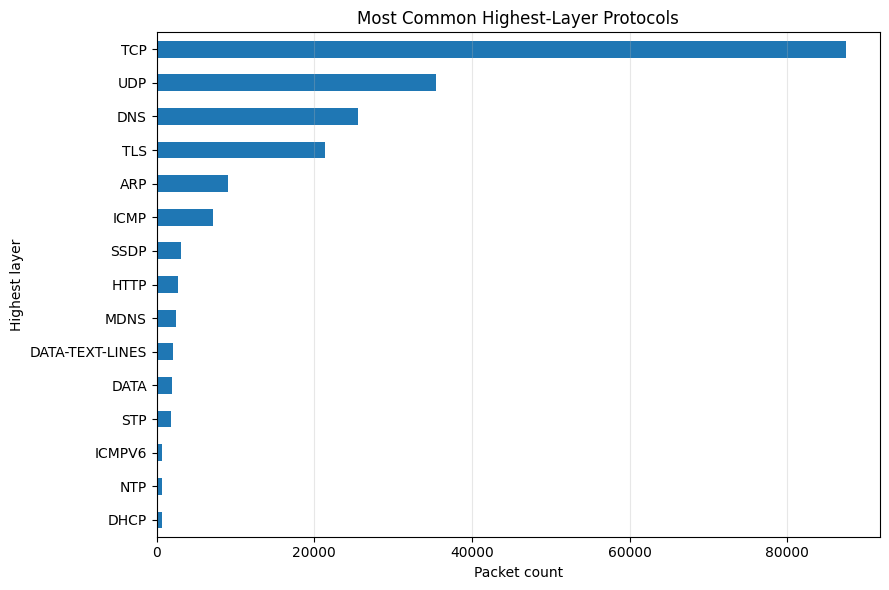

In [12]:

protocol_summary = pd.DataFrame({
    "count": [
        (df["l4_tcp"] == 1).sum(),
        (df["l4_udp"] == 1).sum(),
        ((df["l4_tcp"] == 0) & (df["l4_udp"] == 0)).sum()
    ]
}, index=["TCP", "UDP", "Other"])
protocol_summary["percentage"] = protocol_summary["count"] / len(df) * 100

display(protocol_summary.round(2))

highest_layer_summary = df["highest_layer"].fillna("missing").value_counts().head(15).sort_values()
ax = highest_layer_summary.plot(kind="barh", figsize=(9, 6))
ax.set_xlabel("Packet count")
ax.set_ylabel("Highest layer")
ax.set_title("Most Common Highest-Layer Protocols")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()


In [13]:

activity_summary = pd.DataFrame({
    "active_packets": [
        ((df["http_request_method"].fillna("none") != "none") | (pd.to_numeric(df["http_content_len"], errors="coerce").fillna(0) > 0)).sum(),
        ((df["dns_query_type"].notna()) | (pd.to_numeric(df["dns_len_qry"], errors="coerce").fillna(0) > 0)).sum(),
        ((df["highest_layer"].fillna("").str.upper() == "TLS") | (df["handshake_version"].astype(str) != "-1")).sum(),
        (pd.to_numeric(df["icmp_type"], errors="coerce").fillna(-1) != -1).sum()
    ]
}, index=["HTTP-related", "DNS-related", "TLS-related", "ICMP-related"])
activity_summary["percentage"] = activity_summary["active_packets"] / len(df) * 100

display(activity_summary.round(2))


,active_packets,percentage
HTTP-related,4712,2.30
DNS-related,25539,12.46
TLS-related,21313,10.39
ICMP-related,7109,3.47


## Numeric feature summary

In [14]:

eda_features = [
    "time_since_previously_displayed_frame",
    "inter_arrival_time",
    "jitter",
    "ttl",
    "eth_size",
    "payload_length",
    "payload_entropy",
    "tcp_window_size",
    "stream_5_count",
    "src_ip_5_count",
    "channel_5_count",
    "stream_jitter_5_mean",
    "l3_ip_dst_count"
]

eda_features = [col for col in eda_features if col in df.columns]

display(df[eda_features].describe(percentiles=[0.01, 0.25, 0.50, 0.75, 0.95, 0.99]).T.round(4))


,count,mean,std,min,1%,25%,50%,75%,95%,99%,max
time_since_previously_displayed_frame,205041.0,0.0174,0.0265,0.0000,0.0000,0.0013,0.0073,0.0228,0.0684,0.1236,4.981000e-01
inter_arrival_time,205041.0,3000.1750,10637.1230,0.0002,17.6600,1142.7492,2528.5504,3853.6796,4997.6311,8096.7716,2.546283e+05
jitter,194443.0,42.4262,617.8049,0.0000,0.0000,0.0082,0.0969,0.3283,29.7980,1670.4265,2.476912e+05
ttl,205041.0,93.1911,74.0172,0.0000,0.0000,64.0000,64.0000,122.0000,255.0000,255.0000,2.550000e+02
eth_size,205041.0,206.0951,471.0622,43.0000,60.0000,66.0000,74.0000,164.0000,635.0000,2922.0000,3.047400e+04
payload_length,205041.0,147.0067,470.2761,0.0000,0.0000,0.0000,16.0000,110.0000,569.0000,2856.0000,3.040800e+04
payload_entropy,205041.0,1.8336,1.5886,-0.0000,0.0000,0.0000,2.7290,3.3380,3.5709,3.5839,3.585000e+00
tcp_window_size,205041.0,29949.1743,89856.2993,0.0000,0.0000,0.0000,1025.0000,21472.0000,71680.0000,529152.0000,2.096896e+06
stream_5_count,205041.0,26.9286,81.3377,1.0000,1.0000,2.0000,4.0000,16.0000,123.0000,390.0000,2.126000e+03
src_ip_5_count,191737.0,57.8247,239.6654,1.0000,1.0000,3.0000,15.0000,35.0000,164.0000,1480.0000,4.506000e+03


In [15]:

summary_rows = []

for label, group in df.groupby(BINARY_COL):
    for feature in eda_features:
        values = pd.to_numeric(group[feature], errors="coerce").replace([np.inf, -np.inf], np.nan)
        summary_rows.append({
            BINARY_COL: label,
            "feature": feature,
            "median": values.median(),
            "q1": values.quantile(0.25),
            "q3": values.quantile(0.75),
            "p95": values.quantile(0.95),
            "zero_percentage": (values == 0).mean() * 100
        })

class_numeric_summary = pd.DataFrame(summary_rows)
display(class_numeric_summary.round(4))


,binary_label,feature,median,q1,q3,p95,zero_percentage
0,attack,time_since_previously_displayed_frame,0.0017,0.0001,0.0115,0.0516,2.0036
1,attack,inter_arrival_time,6488.3882,249.2728,10274.3728,249095.4524,0.0000
2,attack,jitter,0.0329,0.0011,0.3192,9.8425,0.0000
3,attack,ttl,64.0000,64.0000,64.0000,255.0000,5.3164
4,attack,eth_size,74.0000,66.0000,352.0000,2922.0000,0.0000
5,attack,payload_length,16.0000,0.0000,298.0000,2856.0000,44.7530
6,attack,payload_entropy,2.8537,0.0000,3.5154,3.5838,44.9316
7,attack,tcp_window_size,14480.0000,0.0000,64256.0000,261248.0000,28.8236
8,attack,stream_5_count,10.0000,3.0000,60.0000,291.0000,0.0000
9,attack,src_ip_5_count,63.0000,6.0000,353.0000,1958.8000,0.0000


## Selected feature distributions

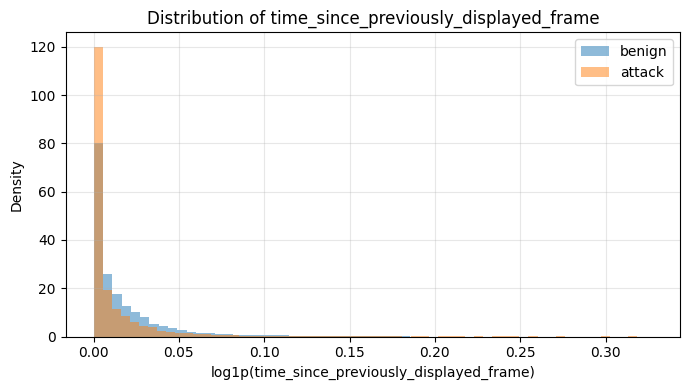

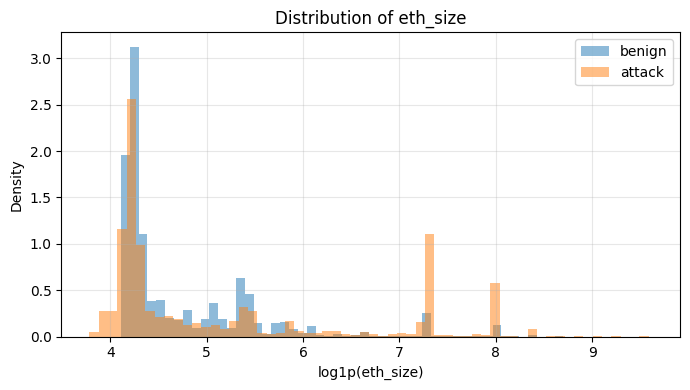

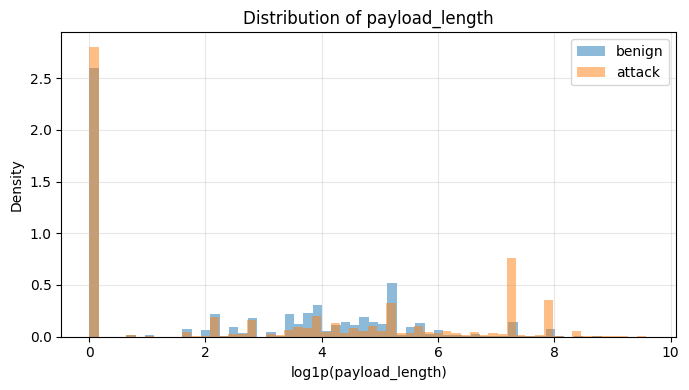

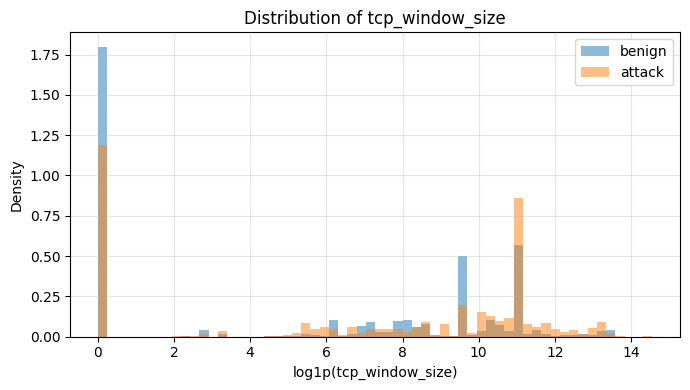

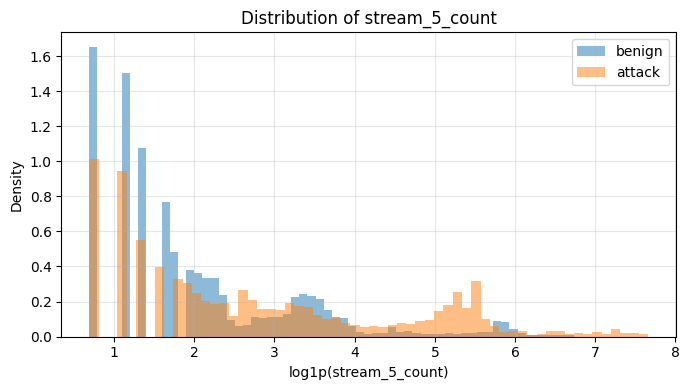

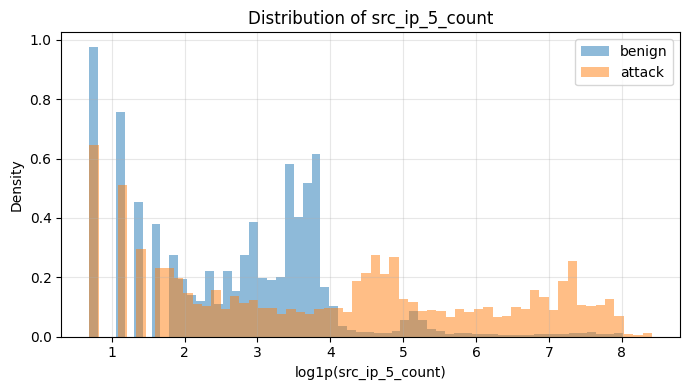

In [16]:

PLOT_SAMPLE_PER_CLASS = 50000
plot_parts = []

for label, group in df.groupby(BINARY_COL):
    sample_size = min(len(group), PLOT_SAMPLE_PER_CLASS)
    plot_parts.append(group.sample(sample_size, random_state=1))

plot_df = pd.concat(plot_parts, ignore_index=True)

distribution_features = [
    "time_since_previously_displayed_frame",
    "eth_size",
    "payload_length",
    "tcp_window_size",
    "stream_5_count",
    "src_ip_5_count"
]
distribution_features = [col for col in distribution_features if col in plot_df.columns]

for feature in distribution_features:
    plt.figure(figsize=(7, 4))

    for label in ["benign", "attack"]:
        values = pd.to_numeric(plot_df.loc[plot_df[BINARY_COL] == label, feature], errors="coerce")
        values = values.replace([np.inf, -np.inf], np.nan).dropna().clip(lower=0)
        plt.hist(np.log1p(values), bins=60, density=True, alpha=0.5, label=label)

    plt.xlabel(f"log1p({feature})")
    plt.ylabel("Density")
    plt.title(f"Distribution of {feature}")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()



The `log1p` transformation is used only for visualization here. It compresses long right tails while preserving zeros. Whether to use the same transformation during preprocessing should be decided from the training data only.


## Median feature values by traffic type

In [17]:

attack_comparison_features = [
    "time_since_previously_displayed_frame",
    "eth_size",
    "payload_length",
    "payload_entropy",
    "tcp_window_size",
    "stream_5_count",
    "src_ip_5_count",
    "channel_5_count"
]
attack_comparison_features = [col for col in attack_comparison_features if col in df.columns]

attack_medians = df.groupby(ATTACK_COL)[attack_comparison_features].median(numeric_only=True)
attack_medians = attack_medians.reindex(type_order).dropna(how="all")
display(attack_medians.round(4))


,time_since_previously_displayed_frame,eth_size,payload_length,payload_entropy,tcp_window_size,stream_5_count,src_ip_5_count,channel_5_count
attack_type,,,,,,,,
Benign,0.0075,74.0,16.0,2.7277,1024.0,4.0,15.0,13.0
DDoS-HTTP Flood,0.0001,74.0,0.0,0.0000,64240.0,5.0,964.0,841.0
DoS-HTTP Flood,0.0003,1514.0,1448.0,3.3452,64256.0,5.0,2036.0,3309.5
DNS Spoofing,0.0035,77.0,16.0,2.9554,2026.0,22.0,22.0,23.0
Brute Force,0.0046,69.0,8.0,1.9324,5535.5,8.0,16.0,20.5
XSS,0.0096,77.0,12.0,2.8830,501.0,6.0,6.0,6.0


## Correlation and redundant numeric features

In [18]:

CORRELATION_SAMPLE_SIZE = 50000
correlation_cols = [col for col in numeric_cols if col not in ["stream"]]
corr_sample = df[correlation_cols].sample(min(len(df), CORRELATION_SAMPLE_SIZE), random_state=1)
corr_sample = corr_sample.replace([np.inf, -np.inf], np.nan)

corr = corr_sample.corr(method="spearman")
upper_mask = np.triu(np.ones(corr.shape), k=1).astype(bool)
correlation_pairs = corr.where(upper_mask).stack().reset_index()
correlation_pairs.columns = ["feature_1", "feature_2", "correlation"]
correlation_pairs["absolute_correlation"] = correlation_pairs["correlation"].abs()
top_correlations = correlation_pairs.sort_values("absolute_correlation", ascending=False).head(25)

display(top_correlations.round(4))


,feature_1,feature_2,correlation,absolute_correlation
12379,q1,q1_e,1.0000,1.0000
12856,sum_p,average_p,1.0000,1.0000
12259,min_et,min_e,1.0000,1.0000
1311,handshake_cipher_suites_length,handshake_extensions_length,1.0000,1.0000
2619,icmp_type,icmp_checksum_status,0.9999,0.9999
10011,stream_jitter_30_mean,stream_jitter_60_mean,0.9963,0.9963
5239,src_ip_5_count,src_ip_mac_5_count,0.9953,0.9953
7024,src_ip_10_count,src_ip_mac_10_count,0.9951,0.9951
10594,src_ip_60_count,src_ip_mac_60_count,0.9945,0.9945
8809,src_ip_30_count,src_ip_mac_30_count,0.9941,0.9941


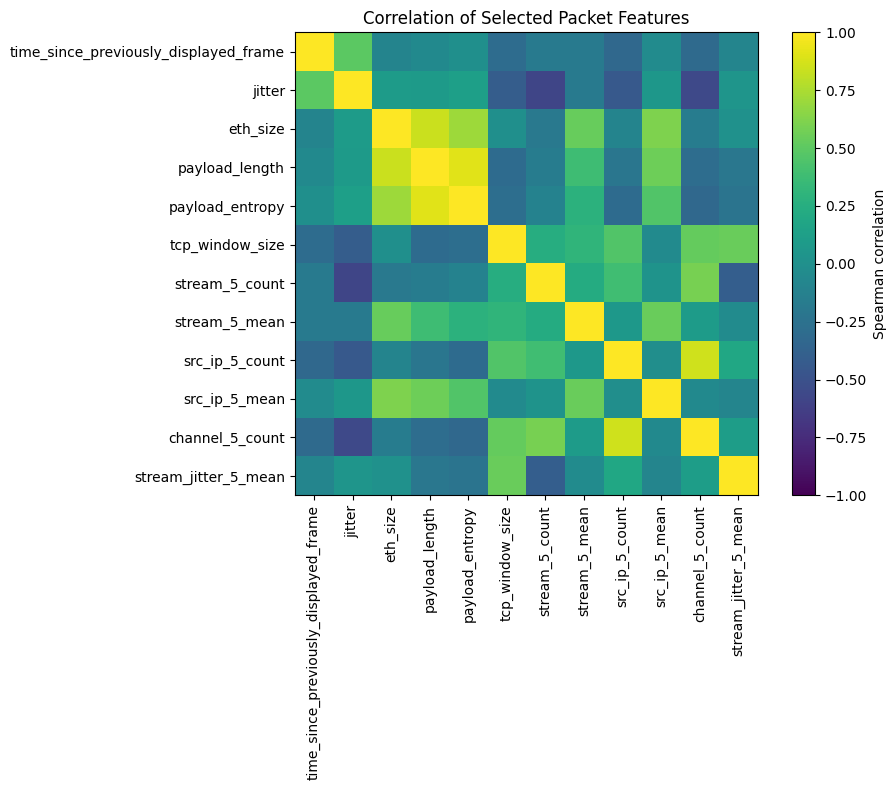

In [19]:

heatmap_features = [
    "time_since_previously_displayed_frame",
    "jitter",
    "eth_size",
    "payload_length",
    "payload_entropy",
    "tcp_window_size",
    "stream_5_count",
    "stream_5_mean",
    "src_ip_5_count",
    "src_ip_5_mean",
    "channel_5_count",
    "stream_jitter_5_mean"
]
heatmap_features = [col for col in heatmap_features if col in corr.columns]
heatmap_corr = corr.loc[heatmap_features, heatmap_features]

plt.figure(figsize=(10, 8))
plt.imshow(heatmap_corr, vmin=-1, vmax=1)
plt.colorbar(label="Spearman correlation")
plt.xticks(range(len(heatmap_features)), heatmap_features, rotation=90)
plt.yticks(range(len(heatmap_features)), heatmap_features)
plt.title("Correlation of Selected Packet Features")
plt.tight_layout()
plt.show()



The rolling-window groups contain many similar count, mean, and variance features measured over 1, 5, 10, 30, and 60 units. Strong correlations are expected. Keeping every window can overweight the same behavior in distance-based models, so the Phase 2 notebooks can start with one representative window and add others only when validation performance improves.


## Skewness and possible outliers

In [20]:

outlier_rows = []

for feature in eda_features:
    values = pd.to_numeric(df[feature], errors="coerce").replace([np.inf, -np.inf], np.nan).dropna()
    q1 = values.quantile(0.25)
    q3 = values.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    outlier_rows.append({
        "feature": feature,
        "skewness": values.skew(),
        "minimum": values.min(),
        "median": values.median(),
        "p99": values.quantile(0.99),
        "maximum": values.max(),
        "iqr_outlier_percentage": ((values < lower) | (values > upper)).mean() * 100
    })

outlier_summary = pd.DataFrame(outlier_rows).sort_values("skewness", key=lambda x: x.abs(), ascending=False)
display(outlier_summary.round(4))


,feature,skewness,minimum,median,p99,maximum,iqr_outlier_percentage
2,jitter,331.8122,0.0000,0.0969,1670.4265,2.476912e+05,21.5904
11,stream_jitter_5_mean,303.5585,0.0000,4.8364,1699.1726,2.476912e+05,17.1459
1,inter_arrival_time,22.5561,0.0002,2528.5504,8096.7716,2.546283e+05,1.0827
10,channel_5_count,8.3613,1.0000,13.0000,2457.6000,5.067000e+03,6.2129
9,src_ip_5_count,8.2051,1.0000,15.0000,1480.0000,4.506000e+03,6.8604
5,payload_length,8.0292,0.0000,16.0000,2856.0000,3.040800e+04,8.8494
4,eth_size,8.0275,43.0000,74.0000,2922.0000,3.047400e+04,10.1853
8,stream_5_count,6.8219,1.0000,4.0000,390.0000,2.126000e+03,11.0992
7,tcp_window_size,6.3107,0.0000,1025.0000,529152.0000,2.096896e+06,18.9465
0,time_since_previously_displayed_frame,3.5249,0.0000,0.0073,0.1236,4.981000e-01,7.3858



Large values are not automatically errors in network traffic. Flooding attacks, retransmissions, bursts, and long idle periods can naturally produce extreme observations. Instead of deleting all IQR outliers, safer first choices are log transformation for non-negative skewed features, robust scaling, or clipping limits learned from the training split.


## Save EDA summary tables

In [ ]:

# REPORT_DIR = PROJECT_ROOT / "reports" / "packet_eda"
# REPORT_DIR.mkdir(parents=True, exist_ok=True)

# binary_summary.to_csv(REPORT_DIR / "binary_class_distribution.csv")
# attack_summary.to_csv(REPORT_DIR / "traffic_type_distribution.csv")
# missing_summary.to_csv(REPORT_DIR / "missing_values.csv")
# object_summary.to_csv(REPORT_DIR / "categorical_cardinality.csv")
# class_numeric_summary.to_csv(REPORT_DIR / "numeric_summary_by_binary_class.csv", index=False)
# top_correlations.to_csv(REPORT_DIR / "top_numeric_correlations.csv", index=False)
# outlier_summary.to_csv(REPORT_DIR / "outlier_summary.csv", index=False)

# print("EDA tables saved to:", REPORT_DIR)


EDA tables saved to: ../reports/packet_eda
